# 7.2) Aprendizagem baseada em instâncias -KNN

In [1]:
import pickle
# read =rb 
with open('../2-3-Classificacao/credit_aula.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

dados credit => [person_income, person_age, loan_amnt | loan_status]

In [69]:
X_credit_treinamento

array([[8.000e+04, 2.200e+01, 7.250e+03],
       [6.700e+04, 3.000e+01, 1.000e+04],
       [5.916e+04, 2.500e+01, 1.660e+04],
       ...,
       [3.850e+04, 2.200e+01, 9.000e+03],
       [4.200e+04, 2.300e+01, 1.000e+04],
       [3.400e+04, 2.300e+01, 1.095e+04]])

In [2]:
X_credit_treinamento.shape, y_credit_treinamento.shape # treinamento

((24435, 3), (24435,))

In [3]:
X_credit_teste.shape, y_credit_teste.shape # testando

((8146, 3), (8146,))

# é um treinamento, não gera um modelo

apenas o cálculo  da distância entre os registros



In [4]:
# vizinhos e classificação
from sklearn.neighbors import KNeighborsClassifier

- padrão


class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

#### metricstr or callable, default=’minkowski’

- Metric to use for distance computation. Default is “minkowski”, which results in the standard Euclidean distance when p = 2. See the documentation of scipy.spatial.distance and the metrics listed in distance_metrics for valid metric values.

If metric is “precomputed”, X is assumed to be a distance matrix and must be square during fit. X may be a sparse graph, in which case only “nonzero” elements may be considered neighbors.

If metric is a callable function, it takes two arrays representing 1D vectors as inputs and must return one value indicating the distance between those vectors. This works for Scipy’s metrics, but is less efficient than passing the metric name as a string.


- pfloat, default=2
- 
Power parameter for the Minkowski metric. When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used. This parameter is expected to be positive.

In [180]:
# pardrão de 5 vizinhos, e  o minkowski é o método de calcular a distância (the distance metric to use for the tree,
# p= padrão de força sendo o 2 a distância euclidiana) .

knn_credit = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p = 2) # tem que passar esses padrões, se não o valor fica o mesmo

knn_credit.fit(X_credit_treinamento, y_credit_treinamento)



KNeighborsClassifier()

In [181]:
# Mostrando os parâmetros
print(knn_credit.get_params())


{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [182]:
# observar as previsões

previsoes = knn_credit.predict(X_credit_teste)
previsoes

array([0, 0, 0, ..., 0, 0, 0])

In [183]:
previsoes[:300]

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0])

Faremos a comparação com os dados teste, ou reais

In [184]:
y_credit_teste[:300]

array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1])

In [185]:
previsoes[8000:]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0])

In [186]:
y_credit_teste[8000:]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1])

### Calculçar a acurácia 

In [187]:
from sklearn.metrics import accuracy_score, classification_report
accuracy_score(y_credit_teste, previsoes) # padronização

0.8276454701694083

In [188]:
acuracia = accuracy_score(y_credit_teste, previsoes)
print(f'Acurácia da instância KNN {acuracia*100:.2f} %') # o ideal é padronizar, tem que estar no mesmo valor de escala

Acurácia da instância KNN 82.76 %


Acurácia da instância KNN 82.76 %, com o n_neighbors=5

Acurácia da instância KNN 84.27 %, com o n_neighbors=10

Acurácia da instância KNN 84.64 %, com o n_neighbors=20


testar na hora de simular com os valores maiores

n_neighbors=20

In [191]:
# acurácia
# comparando com a outra árvore de decisão da base de crédito -> 3-2_Arvore_decisao_parte3_basecredito.ipynb
# a acurácia foi de 81.57 %.
# random forest (muitas árvores) acurácia de 84,21% -> 3-4_Arvore_decision_Random_Forest.ipynb
#  Acurácia do modelo de regras foi de 82.68 % 4-2_InducaoporRegras-BaseCredito.ipynb

# Acurácia da indução de Regras Base Credit do modelo 78.18% 4-3_InducaodeRegras_Base_Credit-Majority_Learner.ipynb 
# ou seja, vale a pena utilizar todos os outros algoritmos utilizados. 

# Acurácia da instância KNN 84.27 %, com o n_neighbors=10


#Acurácia da instância KNN 82.76 %, com o n_neighbors=5 - ideal pois acertou mais o 1x1que é o mais importante, que não paga

0 - pagam

1 - não pagam

valor correto esquerdo 

0x0 e 1x1

0.8276454701694083

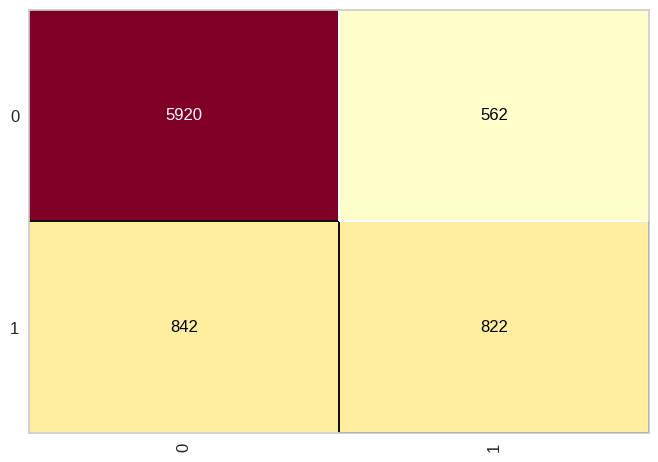

In [190]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(knn_credit)
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [67]:
print(classification_report(y_credit_teste, previsoes))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      6482
           1       0.68      0.43      0.53      1664

    accuracy                           0.84      8146
   macro avg       0.77      0.69      0.72      8146
weighted avg       0.83      0.84      0.83      8146



0 recall pagam 95%, e a precisão de 87%

1 recall que não pagam 43%, e a precisão de 68% ( o que interessa para o banco o 1 não pagam)